Epoch 0, Loss: 366.6627
Epoch 100, Loss: 43.4343
Epoch 200, Loss: 43.1791
Epoch 300, Loss: 43.1898
Epoch 400, Loss: 43.1832
Epoch 500, Loss: 43.2337
Epoch 600, Loss: 43.2083
Epoch 700, Loss: 43.1835
Epoch 800, Loss: 43.2327
Epoch 900, Loss: 43.2301
Final Accuracy: 94.5 %


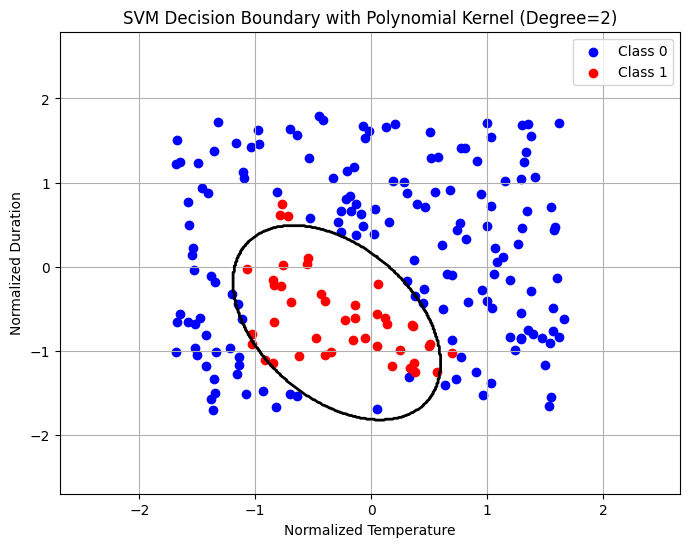

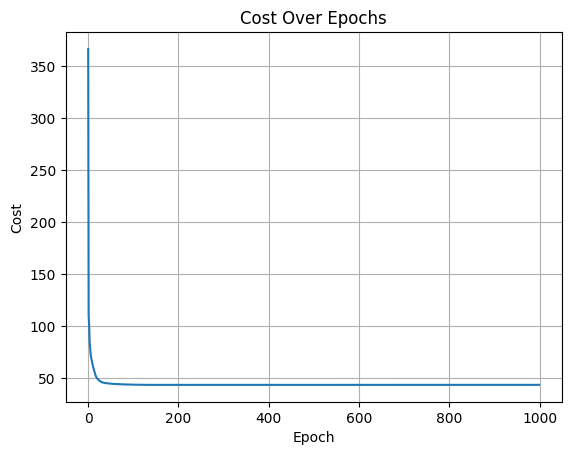

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Load data
def load_coffee_data():
    rng = np.random.default_rng(2)
    X = rng.random(400).reshape(-1, 2)
    X[:, 1] = X[:, 1] * 4 + 11.5
    X[:, 0] = X[:, 0] * (285 - 150) + 150
    Y = np.zeros(len(X))
    for i, (t, d) in enumerate(X):
        y = -3/(260-175)*t + 21
        Y[i] = 1 if (175 < t < 260 and 12 < d < 15 and d <= y) else 0
    return X, Y.reshape(-1, 1)

# Polynomial feature expansion for degree 2
def polynomial_features(X):
    x1 = X[:, 0].reshape(-1, 1)
    x2 = X[:, 1].reshape(-1, 1)
    x1_sq = x1 ** 2
    x2_sq = x2 ** 2
    x1_x2 = x1 * x2
    return np.hstack([x1, x2, x1_sq, x2_sq, x1_x2])

# Load and normalize
X, y = load_coffee_data()
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_norm = (X - X_mean) / X_std
y = y * 2 - 1  # Convert labels to {-1, 1}

# Apply polynomial feature expansion
X_poly = polynomial_features(X_norm)

# Initialize
W = np.random.randn(X_poly.shape[1], 1)
b = 0.0
C = 1.0
lr = 0.01
epochs = 1000
costs = []

# Training loop
for epoch in range(epochs):
    margin = y * (X_poly @ W + b)
    loss = 0.5 * np.sum(W**2) + C * np.sum(np.maximum(0, 1 - margin))
    indicator = (margin < 1).astype(float)
    dW = W - C * (X_poly.T @ (indicator * y))
    db = -C * np.sum(indicator * y)
    W -= lr * dW
    b -= lr * db
    costs.append(loss)
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

# Prediction
y_pred = np.sign(X_poly @ W + b)
acc = np.mean(y_pred.flatten() == y.flatten())
print("Final Accuracy:", acc * 100, "%")

# Decision boundary plotting
xx, yy = np.meshgrid(
    np.linspace(X_norm[:, 0].min() - 1, X_norm[:, 0].max() + 1, 500),
    np.linspace(X_norm[:, 1].min() - 1, X_norm[:, 1].max() + 1, 500)
)
grid = np.c_[xx.ravel(), yy.ravel()]
grid_poly = polynomial_features(grid)
Z = np.sign(grid_poly @ W + b).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contour(xx, yy, Z, levels=[0], colors='k', linewidths=2)
plt.scatter(X_norm[y[:, 0] == -1][:, 0], X_norm[y[:, 0] == -1][:, 1], color='blue', label="Class 0")
plt.scatter(X_norm[y[:, 0] == 1][:, 0], X_norm[y[:, 0] == 1][:, 1], color='red', label="Class 1")
plt.title("SVM Decision Boundary with Polynomial Kernel (Degree=2)")
plt.xlabel("Normalized Temperature")
plt.ylabel("Normalized Duration")
plt.legend()
plt.grid(True)
plt.show()

# Cost plot
plt.plot(costs)
plt.title("Cost Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.grid(True)
plt.show()

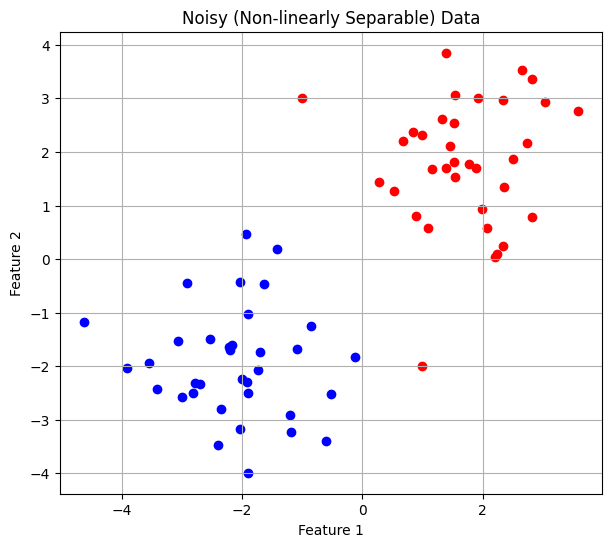

[ 1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.]


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from cvxopt import matrix, solvers

# --- Generate Non-perfectly Separable Dataset ---
np.random.seed(42)
X_pos = np.random.randn(35, 2) + [2, 2]
X_neg = np.random.randn(35, 2) + [-2, -2]
X = np.vstack((X_pos, X_neg))
y = np.hstack((np.ones(35), -1 * np.ones(35)))

# Add noise to make it non-separable
X[10] = [-1, 3]
X[25] = [1, -2]

# --- Plot Function ---
def plot_data(X, y):
    plt.figure(figsize=(7, 6))
    for i in range(len(y)):
        color = 'r' if y[i] == 1 else 'b'
        plt.scatter(X[i][0], X[i][1], color=color)
    plt.title("Noisy (Non-linearly Separable) Data")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.grid(True)
    plt.show()

plot_data(X, y)
print(y)

Epoch 0, Loss: 10.7171
Epoch 100, Loss: 3.2602
Epoch 200, Loss: 3.2665
Epoch 300, Loss: 3.2666
Epoch 400, Loss: 3.2518
Epoch 500, Loss: 3.2512
Epoch 600, Loss: 3.2506
Epoch 700, Loss: 3.2603
Epoch 800, Loss: 3.2501
Epoch 900, Loss: 3.2506
Final Accuracy: 98.57142857142858 %


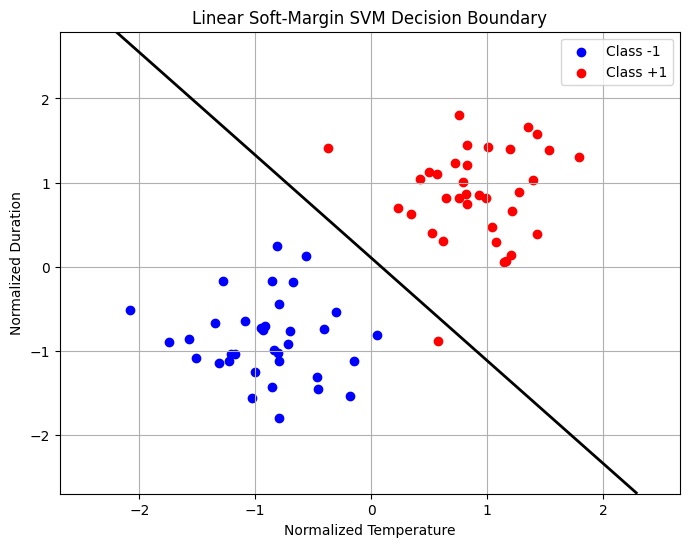

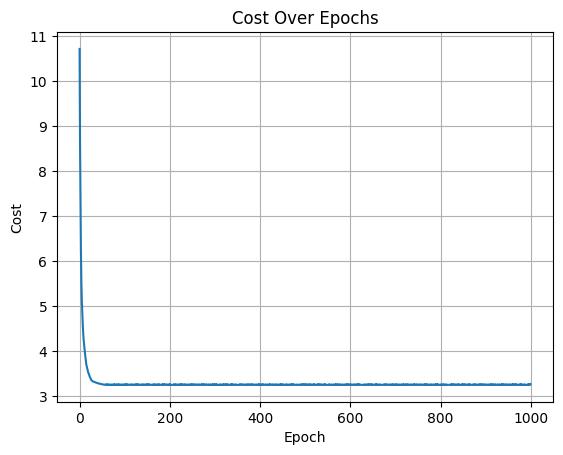

In [4]:
x_norm = (X - np.mean(X,axis=0)) / np.std(X, axis=0)
y = y.reshape(-1, 1)
W = np.random.randn(x_norm.shape[1], 1)
b = 0.0
C = 1.0
lr = 0.01
epochs = 1000
costs = []

# Training loop
for epoch in range(epochs):
    margin = y * (x_norm @ W + b)
    loss = 0.5 * np.sum(W**2) + C * np.sum(np.maximum(0, 1 - margin))
    indicator = (margin < 1).astype(float)
    dW = W - C * (x_norm.T @ (indicator * y))
    db = -C * np.sum(indicator * y)
    W -= lr * dW
    b -= lr * db
    costs.append(loss)
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

# Prediction
y_pred = np.sign(x_norm @ W + b)
acc = np.mean(y_pred.flatten() == y.flatten())
print("Final Accuracy:", acc * 100, "%")

# Decision boundary plotting
xx, yy = np.meshgrid(
    np.linspace(X_norm[:, 0].min() - 1, X_norm[:, 0].max() + 1, 500),
    np.linspace(X_norm[:, 1].min() - 1, X_norm[:, 1].max() + 1, 500)
)
grid = np.c_[xx.ravel(), yy.ravel()]
Z = (grid @ W + b).reshape(xx.shape)


plt.figure(figsize=(8, 6))
plt.contour(xx, yy, Z, levels=[0], colors='k', linewidths=2)
y_flat = y.reshape(-1)
plt.scatter(x_norm[y_flat == -1, 0], x_norm[y_flat == -1, 1], color='blue', label='Class -1')
plt.scatter(x_norm[y_flat == 1, 0], x_norm[y_flat == 1, 1], color='red', label='Class +1')
plt.title("Linear Soft-Margin SVM Decision Boundary")
plt.xlabel("Normalized Temperature")
plt.ylabel("Normalized Duration")
plt.legend()
plt.grid(True)
plt.show()

# Cost plot
plt.plot(costs)
plt.title("Cost Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.grid(True)
plt.show()